<a href="https://colab.research.google.com/github/Kanabee/Bangkok_Public_Issue_Report_Analysis/blob/main/Bangkok_Public_Issue_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bangkok Public Issue Report Analysis

## NLP and Exploratory Data Analysis of Traffy Fondue Reports

This project analyzes public issue reports submitted in Bangkok to identify the most common urban problems, compare issue patterns across districts, and explore recurring topics in Thai-language comments.

**Business question:** How can complaint data be converted into actionable information that helps city teams prioritize problems and allocate resources?

**Tools:** Python, Pandas, Matplotlib, Seaborn, PyThaiNLP, Scikit-learn, and WordCloud

## Project objectives

1. Inspect and clean public issue-report data.
2. Measure reporting volume across Bangkok districts.
3. Classify Thai comments into practical issue categories using transparent keyword rules.
4. Compare both issue volume and issue rate across districts.
5. Discover additional themes with unsupervised text clustering.
6. Translate analytical results into operational recommendations.

## Workflow

`Data collection → Data validation → Data cleaning → Exploratory analysis → Thai text classification → District comparison → Topic discovery → Business insights`

## 1. Environment setup

In [ ]:
%pip -q install pythainlp wordcloud

import re
import warnings
from collections import Counter
from urllib.request import urlretrieve

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

In [ ]:
# ตั้งค่าฟอนต์ภาษาไทยสำหรับ Matplotlib

font_url = "https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf"
font_path = "/content/thsarabunnew-webfont.ttf"

urlretrieve(font_url, font_path)

# เพิ่มฟอนต์เข้า Matplotlib
fm.fontManager.addfont(font_path)

thai_font = fm.FontProperties(fname=font_path)
thai_font_name = thai_font.get_name()

plt.rcParams["font.family"] = thai_font_name
plt.rcParams["font.size"] = 16
plt.rcParams["axes.unicode_minus"] = False

print("Thai font:", thai_font_name)

Thai font: TH Sarabun New


In [ ]:
data = pd.read_csv(DATA_URL)

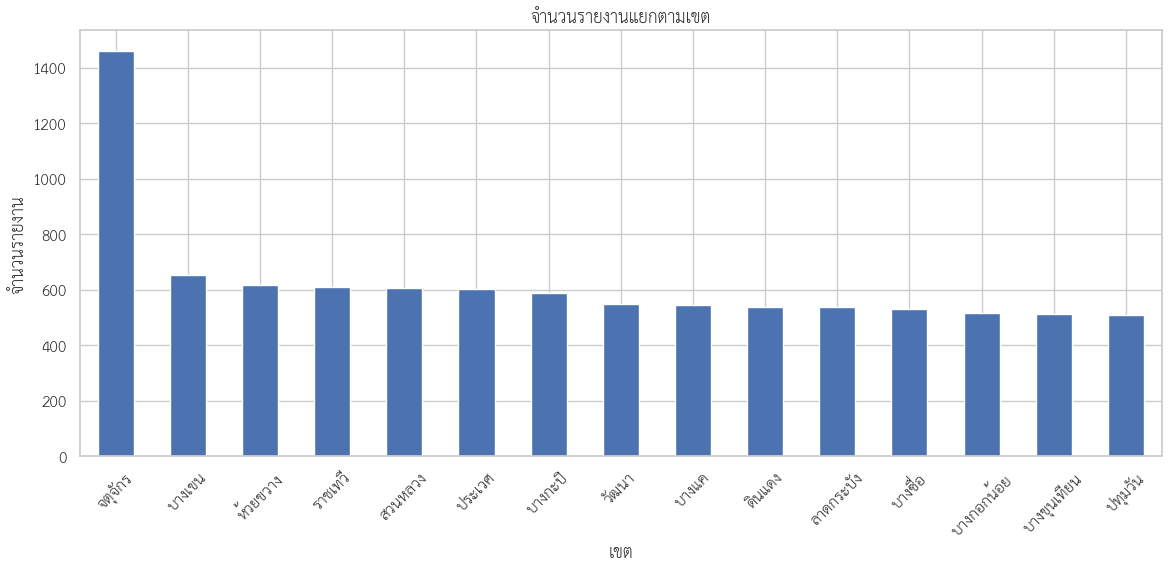

In [ ]:
data["district"].value_counts().head(15).plot.bar(
    figsize=(12, 6)
)

plt.title("จำนวนรายงานแยกตามเขต")
plt.xlabel("เขต")
plt.ylabel("จำนวนรายงาน")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2. Data collection

In [ ]:
DATA_URL = (
    "https://docs.google.com/spreadsheets/d/e/"
    "2PACX-1vT_pDMw6gxubdVtOQele40Wfzfk2XtmryfGfC4kLjwH4oI-uO1jfBGcEmNJlGkLUROa3dQ0iXjdZnOc/"
    "pub?gid=1020716921&single=true&output=csv"
)

raw = pd.read_csv(DATA_URL)
data = raw.copy()

print(f"Rows: {data.shape[0]:,}")
print(f"Columns: {data.shape[1]}")
display(data.head())

Rows: 20,730
Columns: 13


,id,type,comment,ticket_id,coords,photo,after_photo,address,district,subdistrict,province,timestamp,state
0,64202,อื่นๆ,กันที่จอดรถ,2022-GRY4C9,"[100.684183, 13.920973]",https://storage.googleapis.com/traffy_public_bucket/attachment/2022-06/9b86bd4482f50d03db116ed5c9ff6770f907dfe4.jpg,NaN,48/35 ถ. สายไหม แขวง สายไหม เขตสายไหม กรุงเทพมหานคร 10220 ประเทศไทย,สายไหม,สายไหม,กรุงเทพมหานคร,2022-06-12 04:01:00.035653+00,รอรับเรื่อง
1,64201,น้ำท่วม,ผักตบชวาขึ้นในคลองจำนวนมาก ทำให้การระบายน้ำไม่สะดวก และคลองตื้นมาก มีดินโคลนสะสมจำนวนมาก เคยแจ้งทางเขตบางพลัดแล้ว ก็...,2022-A66BE2,"[100.493724010885, 13.7899584498057]",https://storage.googleapis.com/traffy_public_bucket/attachment/2022-06/1d02fe8340e98fe4f58bc350118e88814a012918.jpg,NaN,200 สิรินธร แขวง บางพลัด เขตบางพลัด กรุงเทพมหานคร 10700 ประเทศไทย,บางพลัด,บางพลัด,กรุงเทพมหานคร,2022-06-12 03:59:50.588741+00,ส่งเรื่องแล้ว
2,64199,อื่นๆ,1. รถหามเร่ รถขายของบนถนน,2022-4NNADE,"[100.52675306797, 13.7123723956191]",https://storage.googleapis.com/traffy_public_bucket/attachment/2022-06/1c9490c8b96876b9a7770326aa237cf019728bc2.jpg,NaN,เลขที่ 127/46 หมู่ - หมู่บ้าน - ซอย จันทน์18/7 แยก21 ซอย จันทน์ 18/7 แยก 17 แขวง ทุ่งวัดดอน เขต สาทร กรุงเทพมหานคร 1...,สาทร,ทุ่งวัดดอน,กรุงเทพมหานคร,2022-06-12 03:58:43.913163+00,รอรับเรื่อง
3,64198,อื่นๆ,สน. พหลโยธิน เค้าจะรื้อถอนไหมครับ เพราะทางเท้า เป็นของเขต ห้วยขวาง รับผิดชอบ และ ทาง สน. ตั้งป้อมจราจร ผิดกฏหมาย ทาง...,2022-D328VH,"[100.5836, 13.800689]",https://storage.googleapis.com/traffy_public_bucket/attachment/2022-06/ab75a3fc73ff8912e86645c353be5f6947a0861d.jpg,NaN,1429 ซอย ลาดพร้าว 41 แยก 6-4 แขวง สามเสนนอก เขตห้วยขวาง กรุงเทพมหานคร 10310 ประเทศไทย,ห้วยขวาง,สามเสนนอก,กรุงเทพมหานคร,2022-06-12 03:58:27.202716+00,รอรับเรื่อง
4,64197,อื่นๆ,จอดส่งของ,2022-EAP43H,"[100.684183, 13.920973]",https://storage.googleapis.com/traffy_public_bucket/attachment/2022-06/6628398731edec04bcba92d5dc15d5901fcd29a9.jpg,NaN,48/35 ถ. สายไหม แขวง สายไหม เขตสายไหม กรุงเทพมหานคร 10220 ประเทศไทย,สายไหม,สายไหม,กรุงเทพมหานคร,2022-06-12 03:58:19.000336+00,รอรับเรื่อง


## 3. Data validation and cleaning

The validation step checks schema, data types, missing values, and duplicated records. Text and location fields are standardized before analysis. Invalid timestamps are converted to missing values instead of stopping the workflow.

In [ ]:
display(data.info())

quality_report = pd.DataFrame({
    "dtype": data.dtypes.astype(str),
    "missing_count": data.isna().sum(),
    "missing_percent": (data.isna().mean() * 100).round(2),
    "unique_values": data.nunique(dropna=True),
}).sort_values("missing_percent", ascending=False)

display(quality_report)
print(f"Duplicated rows: {data.duplicated().sum():,}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20730 entries, 0 to 20729
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           20730 non-null  int64 
 1   type         20730 non-null  object
 2   comment      20730 non-null  object
 3   ticket_id    20725 non-null  object
 4   coords       20730 non-null  object
 5   photo        20730 non-null  object
 6   after_photo  2708 non-null   object
 7   address      20730 non-null  object
 8   district     20728 non-null  object
 9   subdistrict  20730 non-null  object
 10  province     20730 non-null  object
 11  timestamp    20730 non-null  object
 12  state        20730 non-null  object
dtypes: int64(1), object(12)
memory usage: 2.1+ MB


None

,dtype,missing_count,missing_percent,unique_values
after_photo,object,18022,86.94,2708
ticket_id,object,5,0.02,20725
district,object,2,0.01,65
id,int64,0,0.00,20730
type,object,0,0.00,7
coords,object,0,0.00,18290
comment,object,0,0.00,17362
photo,object,0,0.00,20730
address,object,0,0.00,14574
subdistrict,object,0,0.00,202


Duplicated rows: 0


In [ ]:
required_columns = {"comment", "district", "subdistrict", "timestamp", "state"}
missing_columns = required_columns.difference(data.columns)
if missing_columns:
    raise ValueError(f"Required columns are missing: {sorted(missing_columns)}")

data = data.drop_duplicates().copy()

text_columns = ["comment", "district", "subdistrict", "province", "state", "type"]
for column in [c for c in text_columns if c in data.columns]:
    data[column] = data[column].fillna("").astype(str).str.strip()

data["timestamp"] = pd.to_datetime(data["timestamp"], errors="coerce", utc=True)
data["date"] = data["timestamp"].dt.date
data["month"] = data["timestamp"].dt.to_period("M").astype(str)

# Remove records without usable text for NLP analysis.
analysis_data = data.loc[data["comment"].str.len() > 0].copy()

print(f"Rows after cleaning: {analysis_data.shape[0]:,}")
print(f"Rows removed: {raw.shape[0] - analysis_data.shape[0]:,}")

Rows after cleaning: 20,730
Rows removed: 0


## 4. Exploratory data analysis

In [ ]:
summary = pd.Series({
    "Total reports": len(analysis_data),
    "Districts": analysis_data["district"].replace("", np.nan).nunique(),
    "Subdistricts": analysis_data["subdistrict"].replace("", np.nan).nunique(),
    "Start date": analysis_data["timestamp"].min(),
    "End date": analysis_data["timestamp"].max(),
})
display(summary.to_frame("value"))

,value
Total reports,20730
Districts,65
Subdistricts,202
Start date,2022-05-25 17:44:19.135957+00:00
End date,2022-06-12 04:01:00.035653+00:00


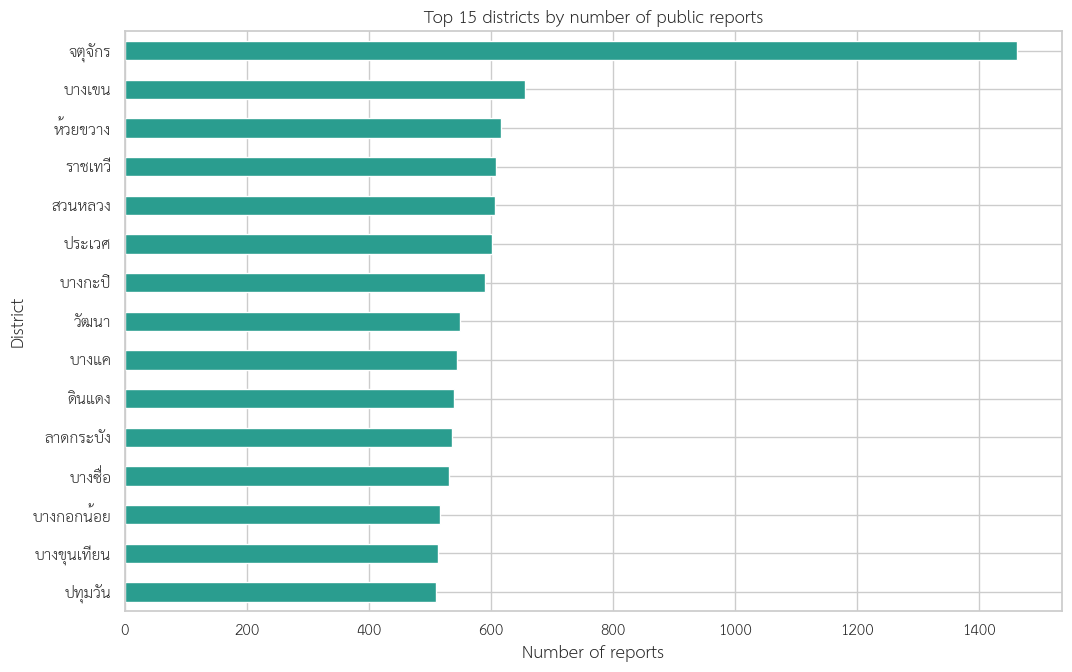

In [ ]:
district_counts = (
    analysis_data.loc[analysis_data["district"] != "", "district"]
    .value_counts()
    .head(15)
    .sort_values()
)

ax = district_counts.plot(kind="barh", figsize=(11, 7), color="#2A9D8F")
ax.set_title("Top 15 districts by number of public reports")
ax.set_xlabel("Number of reports")
ax.set_ylabel("District")
plt.tight_layout()
plt.show()

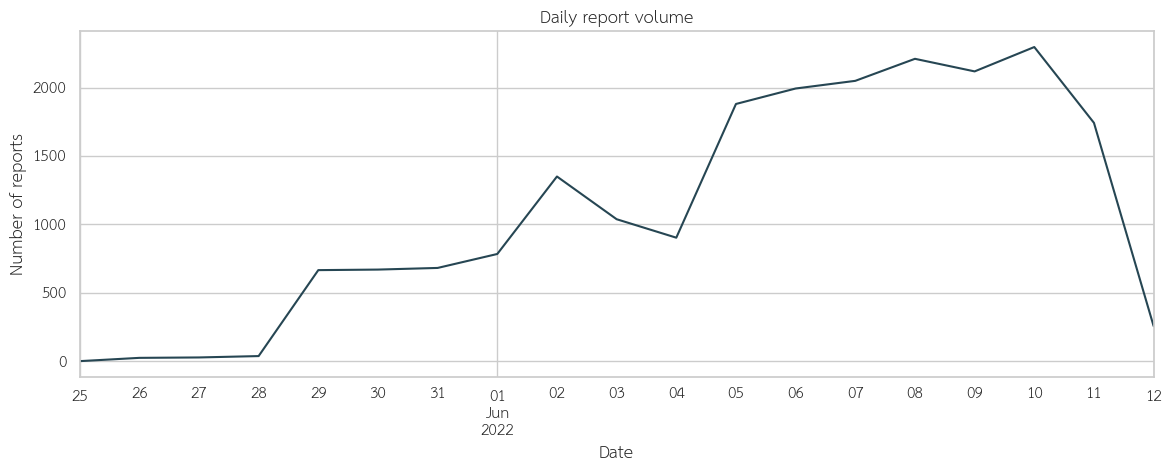

In [ ]:
if analysis_data["timestamp"].notna().any():
    daily_reports = analysis_data.set_index("timestamp").resample("D").size()
    ax = daily_reports.plot(figsize=(12, 5), color="#264653")
    ax.set_title("Daily report volume")
    ax.set_xlabel("Date")
    ax.set_ylabel("Number of reports")
    plt.tight_layout()
    plt.show()

## 5. Rule-based Thai issue classification

A keyword dictionary is used to create explainable issue flags. A report may belong to more than one category because real complaints often mention multiple problems. This approach is easy for non-technical stakeholders to review and update.

In [ ]:
ISSUE_KEYWORDS = {
    "น้ำท่วม/ระบายน้ำ": ["น้ำท่วม", "น้ำขัง", "ระบายน้ำ", "ท่ออุดตัน", "ฝนตก"],
    "แสงสว่าง": ["มืด", "ไฟดับ", "ไฟส่องสว่าง", "เปลี่ยว"],
    "จราจร": ["รถติด", "จราจร", "การจราจร", "ติดขัด"],
    "ทางข้าม": ["ทางม้าลาย", "ม้าลาย", "ข้ามถนน"],
    "ขยะ/กลิ่น/น้ำเสีย": ["สกปรก", "ขยะ", "เหม็น", "กลิ่น", "น้ำเสีย"],
    "สัตว์": ["แมว", "สุนัข", "หมา", "จรจัด", "สัตว์"],
    "ทางเท้า": ["ทางเดิน", "ทางเท้า", "ฟุตบาท", "กีดขวาง", "จอดรถบนทางเท้า"],
    "ถนน": ["หลุม", "ถนนพัง", "ถนนชำรุด", "ถนนขรุขระ", "ป้ายบอกทาง"],
    "สายไฟ/ความเป็นระเบียบ": ["สายไฟ", "ไม่เป็นระเบียบ", "สายสื่อสาร"],
    "ต้นไม้": ["ต้นไม้", "กิ่งไม้"],
    "ความปลอดภัย": ["ไม่ปลอดภัย", "อันตราย", "เสี่ยงอุบัติเหตุ"],
}


def add_issue_flags(df, text_column="comment"):
    result = df.copy()
    text = result[text_column].fillna("").astype(str)
    for issue, keywords in ISSUE_KEYWORDS.items():
        pattern = "|".join(re.escape(word) for word in keywords)
        result[issue] = text.str.contains(pattern, case=False, regex=True).astype(int)
    return result


classified = add_issue_flags(analysis_data)
issue_columns = list(ISSUE_KEYWORDS)
classified["classified_issue_count"] = classified[issue_columns].sum(axis=1)

coverage = (classified["classified_issue_count"] > 0).mean() * 100
print(f"Reports matched to at least one issue category: {coverage:.2f}%")

Reports matched to at least one issue category: 64.46%


,report_count,share_percent
ทางเท้า,4351.0,20.99
จราจร,2257.0,10.89
ขยะ/กลิ่น/น้ำเสีย,2110.0,10.18
น้ำท่วม/ระบายน้ำ,2091.0,10.09
ความปลอดภัย,1717.0,8.28
แสงสว่าง,1560.0,7.53
ถนน,1514.0,7.30
สายไฟ/ความเป็นระเบียบ,917.0,4.42
สัตว์,858.0,4.14
ทางข้าม,750.0,3.62


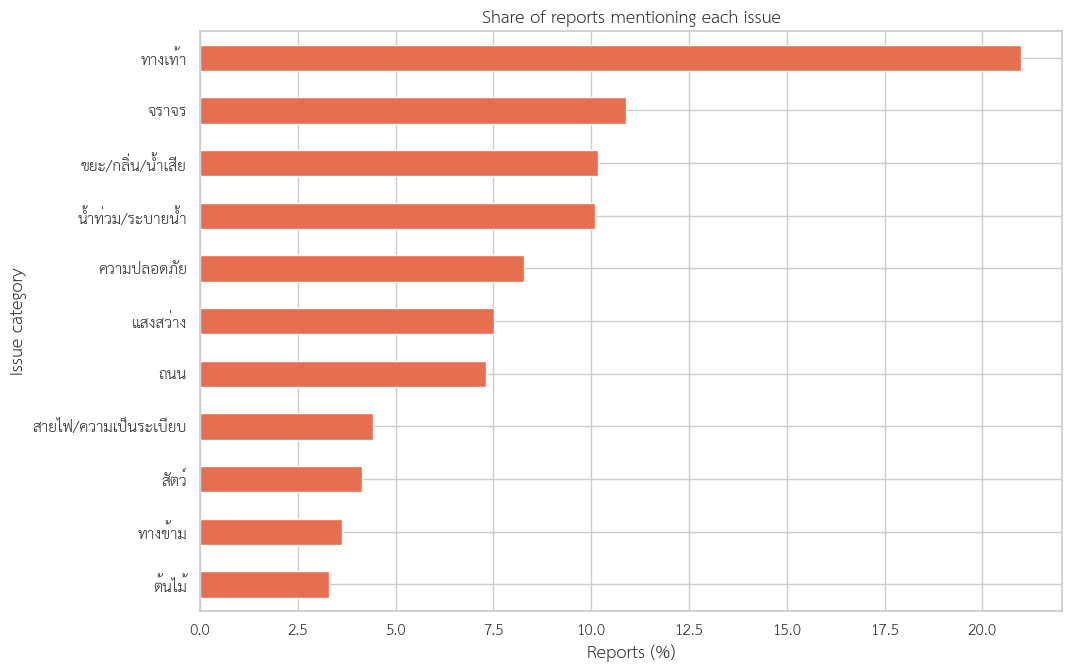

In [ ]:
issue_summary = (
    classified[issue_columns]
    .agg(["sum", "mean"])
    .T
    .rename(columns={"sum": "report_count", "mean": "share"})
)
issue_summary["share_percent"] = issue_summary["share"] * 100
issue_summary = issue_summary.sort_values("report_count", ascending=False)

display(issue_summary[["report_count", "share_percent"]].round(2))

ax = issue_summary.sort_values("share_percent")["share_percent"].plot(
    kind="barh", figsize=(11, 7), color="#E76F51"
)
ax.set_title("Share of reports mentioning each issue")
ax.set_xlabel("Reports (%)")
ax.set_ylabel("Issue category")
plt.tight_layout()
plt.show()

## 6. District-level comparison

Raw complaint counts may favor districts with more residents or more active reporters. Therefore, this section reports both:

- **Issue volume:** number of matched reports.
- **Issue rate:** percentage of all reports in a district that mention the issue.

Districts with very few reports are excluded from rate rankings to reduce unstable comparisons.

In [ ]:
MIN_DISTRICT_REPORTS = 100

district_total = classified.groupby("district").size().rename("total_reports")
eligible_districts = district_total[district_total >= MIN_DISTRICT_REPORTS].index

district_issue_count = classified.groupby("district")[issue_columns].sum()
district_issue_rate = district_issue_count.div(district_total, axis=0) * 100
district_issue_rate = district_issue_rate.loc[eligible_districts]

selected_issue = issue_summary.index[0]
comparison = pd.DataFrame({
    "issue_reports": district_issue_count.loc[eligible_districts, selected_issue],
    "issue_rate_percent": district_issue_rate[selected_issue],
    "all_reports": district_total.loc[eligible_districts],
}).sort_values("issue_rate_percent", ascending=False)

print(f"District comparison for: {selected_issue}")
display(comparison.head(10).round(2))

District comparison for: ทางเท้า


,issue_reports,issue_rate_percent,all_reports
district,,,
ป้อมปราบศัตรูพ่าย,109,42.58,256
พระนคร,93,32.98,282
วัฒนา,166,30.18,550
บางนา,119,29.82,399
ปทุมวัน,144,28.24,510
จตุจักร,410,28.04,1462
จอมทอง,125,27.41,456
บางพลัด,127,27.14,468
คลองเตย,122,27.05,451


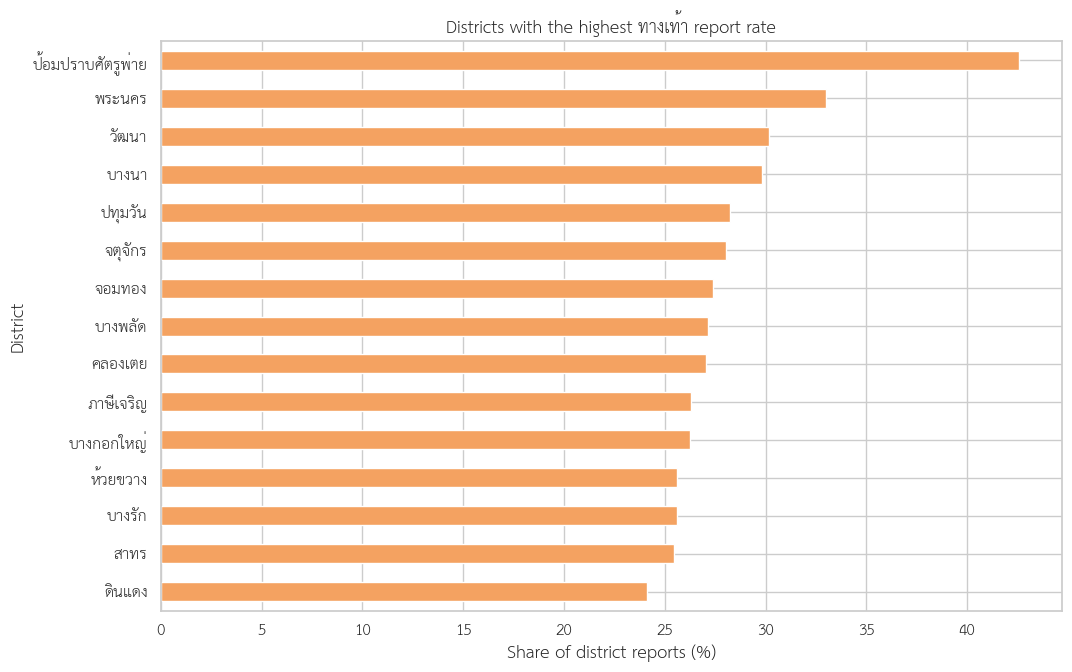

In [ ]:
top_districts = comparison.head(15).sort_values("issue_rate_percent")
ax = top_districts["issue_rate_percent"].plot(kind="barh", figsize=(11, 7), color="#F4A261")
ax.set_title(f"Districts with the highest {selected_issue} report rate")
ax.set_xlabel("Share of district reports (%)")
ax.set_ylabel("District")
plt.tight_layout()
plt.show()

## 7. Thai word-frequency visualization

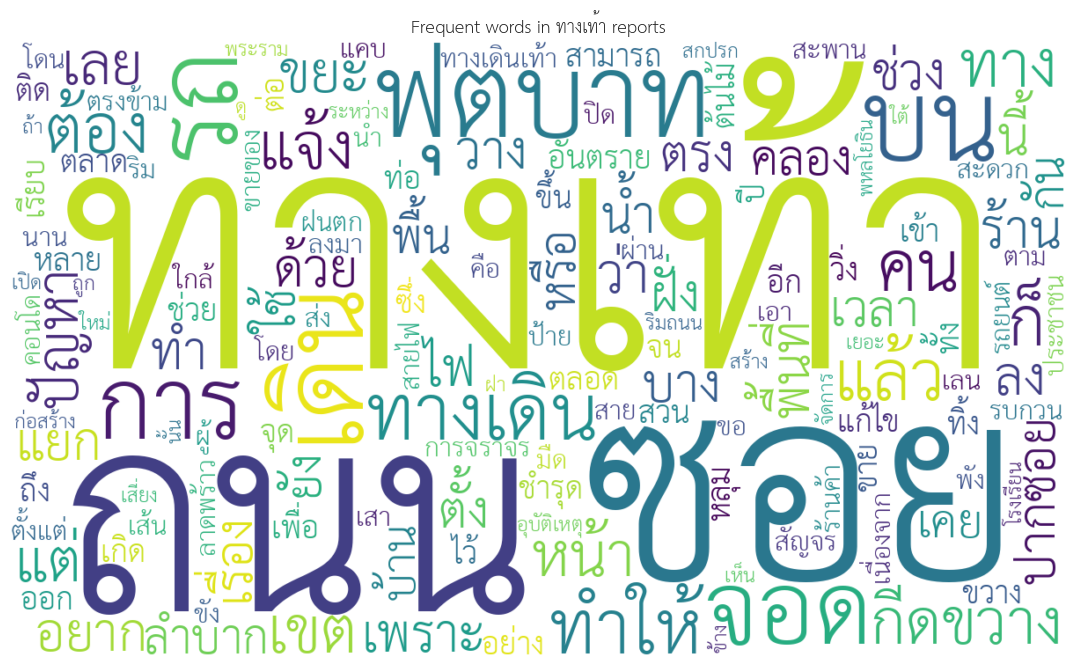

In [ ]:
THAI_STOPWORDS = {
    "ที่", "และ", "มี", "เป็น", "ให้", "ของ", "ใน", "ไม่", "ได้", "จะ", "กับ",
    "จาก", "บริเวณ", "ครับ", "ค่ะ", "ค่ะ", "นะ", "อยู่", "มาก", "ไป", "มา",
}


def thai_word_frequencies(text_series):
    tokens = []
    for text in text_series.dropna().astype(str):
        tokens.extend(word_tokenize(text, engine="newmm", keep_whitespace=False))
    return Counter(
        token.strip()
        for token in tokens
        if len(token.strip()) > 1 and token.strip() not in THAI_STOPWORDS
    )


selected_comments = classified.loc[classified[selected_issue] == 1, "comment"]
frequencies = thai_word_frequencies(selected_comments)

wordcloud = WordCloud(
    font_path=font_path,
    width=1200,
    height=700,
    background_color="white",
    colormap="viridis",
    max_words=150,
    collocations=False,
).generate_from_frequencies(frequencies)

plt.figure(figsize=(14, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.title(f"Frequent words in {selected_issue} reports")
plt.axis("off")
plt.show()

## 8. Unsupervised topic discovery

Keyword rules only detect predefined issues. To explore themes not covered by the dictionary, comments are converted into TF-IDF character n-gram features and grouped with MiniBatch K-Means. Character n-grams are practical for Thai because they do not depend entirely on word-boundary detection.

In [ ]:
N_CLUSTERS = 15

vectorizer = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=5,
    max_df=0.95,
    max_features=12_000,
    sublinear_tf=True,
)

tfidf = vectorizer.fit_transform(classified["comment"])

cluster_model = MiniBatchKMeans(
    n_clusters=N_CLUSTERS,
    random_state=RANDOM_STATE,
    batch_size=1_024,
    n_init=10,
)

classified["topic_cluster"] = cluster_model.fit_predict(tfidf)
print(f"TF-IDF matrix: {tfidf.shape}")
display(classified["topic_cluster"].value_counts().sort_index().to_frame("reports"))

TF-IDF matrix: (20730, 12000)


,reports
topic_cluster,
0,1342
1,639
2,5782
3,1016
4,460
5,616
6,1042
7,1161
8,704


In [ ]:
feature_names = np.array(vectorizer.get_feature_names_out())
cluster_terms = []

for cluster_id, center in enumerate(cluster_model.cluster_centers_):
    top_terms = feature_names[center.argsort()[-12:][::-1]]
    cluster_terms.append({
        "cluster": cluster_id,
        "reports": int((classified["topic_cluster"] == cluster_id).sum()),
        "representative_ngrams": ", ".join(top_terms),
    })

cluster_summary = pd.DataFrame(cluster_terms).sort_values("reports", ascending=False)
display(cluster_summary)

,cluster,reports,representative_ngrams
2,2,5782,"ค่ะ, ่ะ , ค่ะ , ไม่, ขยะ, ถนน, ซอย, จ้ง, แจ้, แจ้ง, ที่, ื่อ"
9,9,4045,"ที่, ให้, การ, จอด, ไม่, นที, นที่, ้าน, และ, เป็, ป็น, เป็น"
13,13,2131,"ครับ, ครับ , รับ , ครั, ับ , รับ, สาย, สายไฟ, ายไฟ, ยไฟ, สายไ, สาย"
0,0,1342,"เดิน, ดิน, เดิ, งเดิน, งเดิ, งเด, างเดิ, ทางเด, างเด, ทางเ, างเ, ทาง"
7,7,1161,"้าลาย, ้าลา, าลาย, ม้าลา, ม้าล, ม้า, ้าล, งม้า, งม้, ทางม้, างม้า, างม้"
6,6,1042,"ุตบา, ุตบ, ฟุตบา, ฟุตบ, ฟุต, ท่อ, ุตบาท, ตบาท, าท่อ, ฝาท, บาท, ฝาท่"
3,3,1016,"างเท้, งเท้า, งเท้, ทางเท, างเท, เท้า, เท้, งเท, ท้า, ทางเ, างเ, เท้า"
11,11,753,"สะพ, สะพา, ะพา, ะพาน, สะพาน, พาน, านลอ, พานล, านลอย, ะพานล, พานลอ, นลอย"
8,8,704,"ิเหต, ติเหต, ิเห, ติเห, อุบ, ัติเห, อุบั, อุบัต, ุบัต, ิเหตุ, ัติเ, บัติเ"
10,10,670,"สว่าง, สว่า, สว่, งสว่, งสว่า, งสว, ว่าง, ส่อง, ส่อ, ส่องส, องสว่, ่องสว"


In [ ]:
def show_cluster_examples(cluster_id, n=5):
    columns = [c for c in ["ticket_id", "district", "comment"] if c in classified.columns]
    return classified.loc[classified["topic_cluster"] == cluster_id, columns].head(n)


largest_cluster = int(cluster_summary.iloc[0]["cluster"])
print(f"Example reports from cluster {largest_cluster}")
display(show_cluster_examples(largest_cluster))

Example reports from cluster 2


,ticket_id,district,comment
2,2022-4NNADE,สาทร,1. รถหามเร่ รถขายของบนถนน
4,2022-EAP43H,สายไหม,จอดส่งของ
5,2022-MDBFQK,วัฒนา,หน่วยงานไม่เก็บขยะ
15,2022-PBVYQV,หนองจอก,การระบายน้ำในซอยมิตรไมตรี 12 น้ำไม่สามารถระบายได้ทันทำให้เกิดเน่าของเสีย
16,2022-649ZHY,ดอนเมือง,อยากให้จัดการแท็กซี่ที่ชอบจอดแช่ตรงป้ายรถเมลฺ


## 9. Automated analytical summary

In [ ]:
top_issue = issue_summary.index[0]
top_issue_share = issue_summary.loc[top_issue, "share_percent"]
highest_volume_district = district_total.idxmax()
highest_volume = district_total.max()
top_rate_district = district_issue_rate[top_issue].idxmax()
top_rate = district_issue_rate.loc[top_rate_district, top_issue]

print("KEY FINDINGS")
print("-" * 60)
print(f"1. Most frequently identified issue: {top_issue} ({top_issue_share:.2f}% of reports).")
print(f"2. District with the largest reporting volume: {highest_volume_district} ({highest_volume:,} reports).")
print(f"3. Highest {top_issue} rate among eligible districts: {top_rate_district} ({top_rate:.2f}%).")
print(f"4. Rule-based issue coverage: {coverage:.2f}% of reports.")
print(f"5. Topic discovery grouped the comments into {N_CLUSTERS} exploratory clusters.")

KEY FINDINGS
------------------------------------------------------------
1. Most frequently identified issue: ทางเท้า (20.99% of reports).
2. District with the largest reporting volume: จตุจักร (1,462 reports).
3. Highest ทางเท้า rate among eligible districts: ป้อมปราบศัตรูพ่าย (42.58%).
4. Rule-based issue coverage: 64.46% of reports.
5. Topic discovery grouped the comments into 15 exploratory clusters.


## 10. Business interpretation and recommendations

- Prioritize issues using both **volume and rate**. High volume indicates workload, while a high within-district rate may indicate a concentrated local problem.
- Route issue categories to responsible operational teams and monitor unresolved-report aging by district.
- Review unmatched comments regularly and use the clustering results to expand the issue dictionary.
- Track issue rates over time to distinguish recurring structural problems from short-lived incidents.
- Combine report data with population, road length, rainfall, and service-capacity data before making resource-allocation decisions.

## Limitations

- Reports represent platform users and may not represent the entire Bangkok population.
- Keyword classification can miss synonyms, spelling variations, sarcasm, and context.
- A report may contain several issues, so category percentages are not mutually exclusive.
- Complaint counts are not equal to the number of unique physical incidents.
- Clusters are exploratory and require human review before being assigned operational labels.

## Next steps

1. Add spelling normalization and a reviewed Thai synonym dictionary.
2. Build a manually labeled sample and evaluate classification precision, recall, and F1-score.
3. Add geographical maps using validated coordinates.
4. Create an interactive dashboard for district and time-period filtering.
5. Monitor resolution time and status changes to measure service performance.